In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import linregress

Loading in the data and interpolate missing data

In [2]:
data = pd.read_csv("mohembo_daily_water_discharge_data.csv", index_col='date', parse_dates=True, dayfirst=True)
data_daily = data.resample('D').interpolate()
data_daily.columns = ['Discharge (m^3/s)']
data_daily = data_daily[~data_daily.index.year.isin([1974, 2021])]

Plotting the daily data

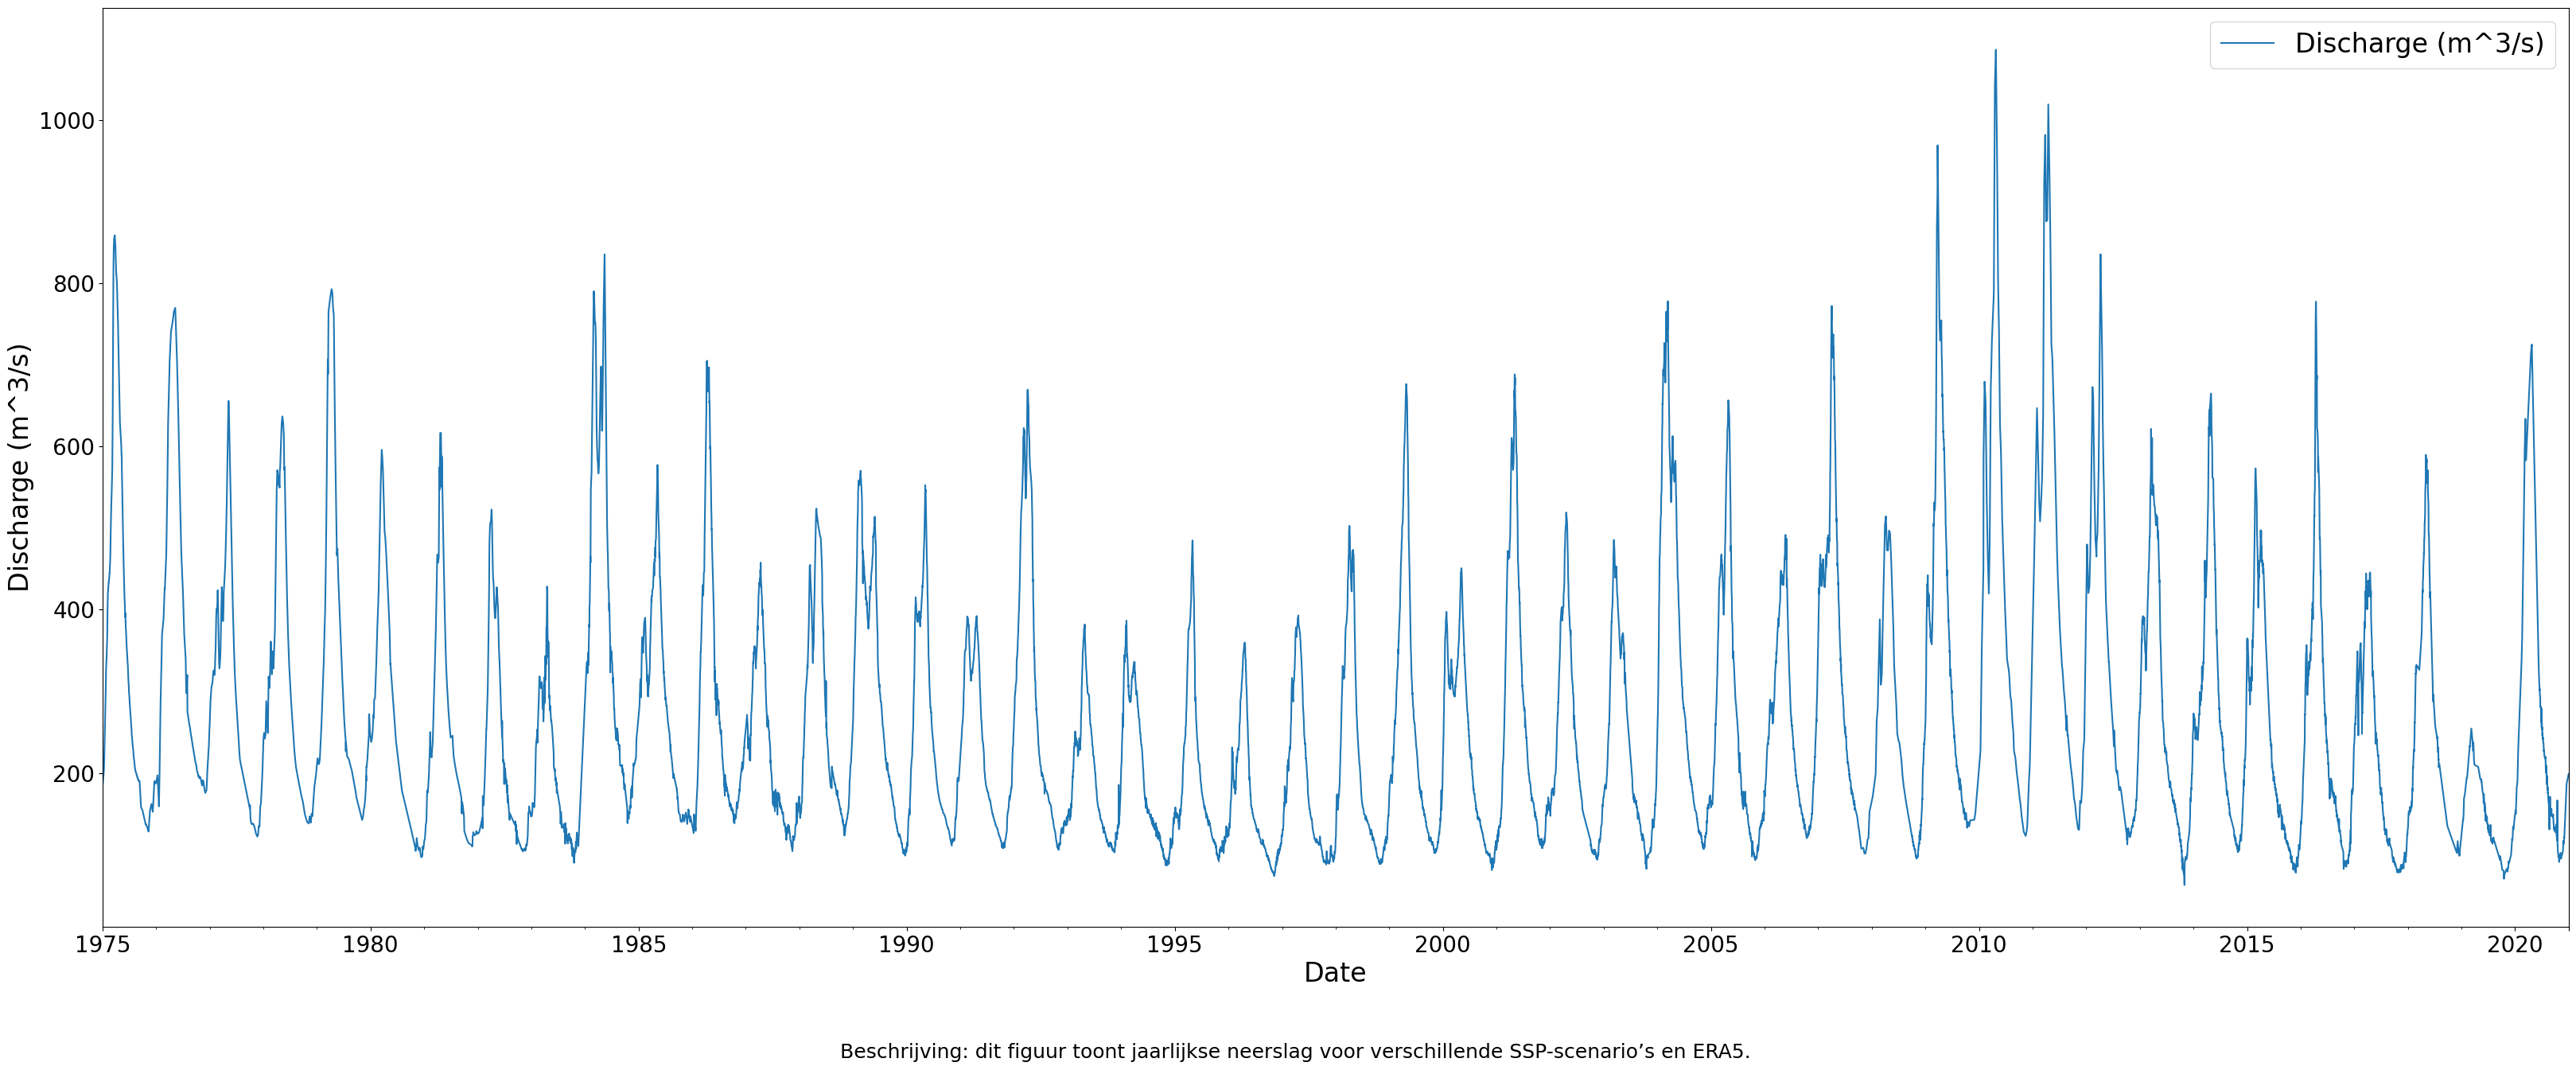

In [9]:
fig, ax = plt.subplots(figsize=(40, 15))
data_daily.plot(ax=ax)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.set_xlabel("Date", fontsize=24)
ax.set_ylabel("Discharge (m^3/s)", fontsize=24)
plt.legend(fontsize=24);

fig.text(
    0.5, 0,
    "Beschrijving: dit figuur toont jaarlijkse neerslag voor verschillende SSP-scenario’s en ERA5.",
    ha="center",
    fontsize=18
);

Yearly max discharge

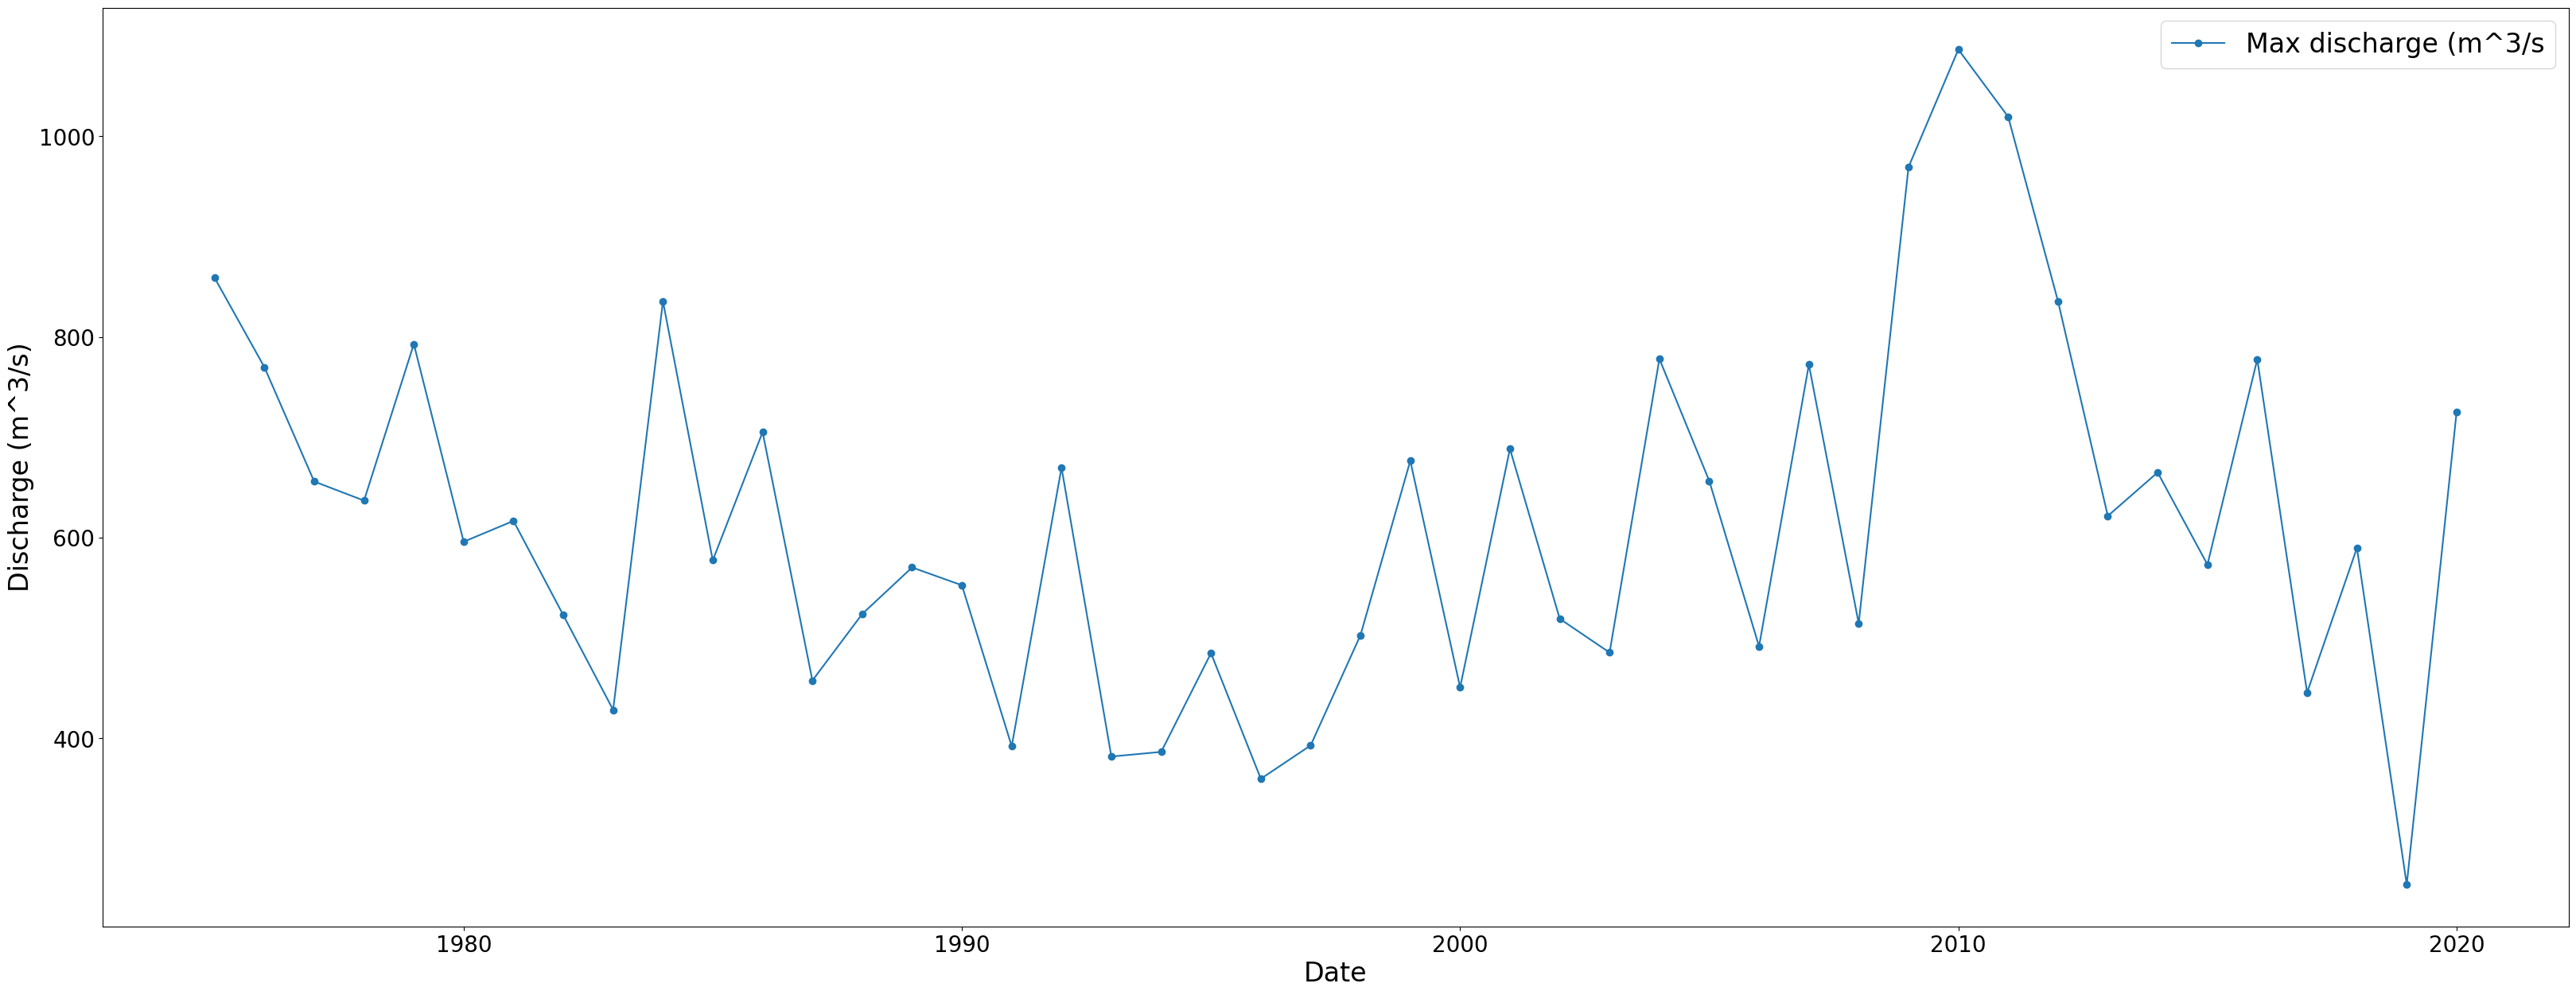

In [4]:
yearly_max = data_daily.resample('YE').max()
yearly_max.index = yearly_max.index.year
yearly_max.columns = ['Max discharge (m^3/s']

fig, ax = plt.subplots(figsize=(40, 15))
yearly_max.plot(ax=ax, marker='o')
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.set_xlabel("Date", fontsize=24)
ax.set_ylabel("Discharge (m^3/s)", fontsize=24)
plt.legend(fontsize=24);

Yearly volume

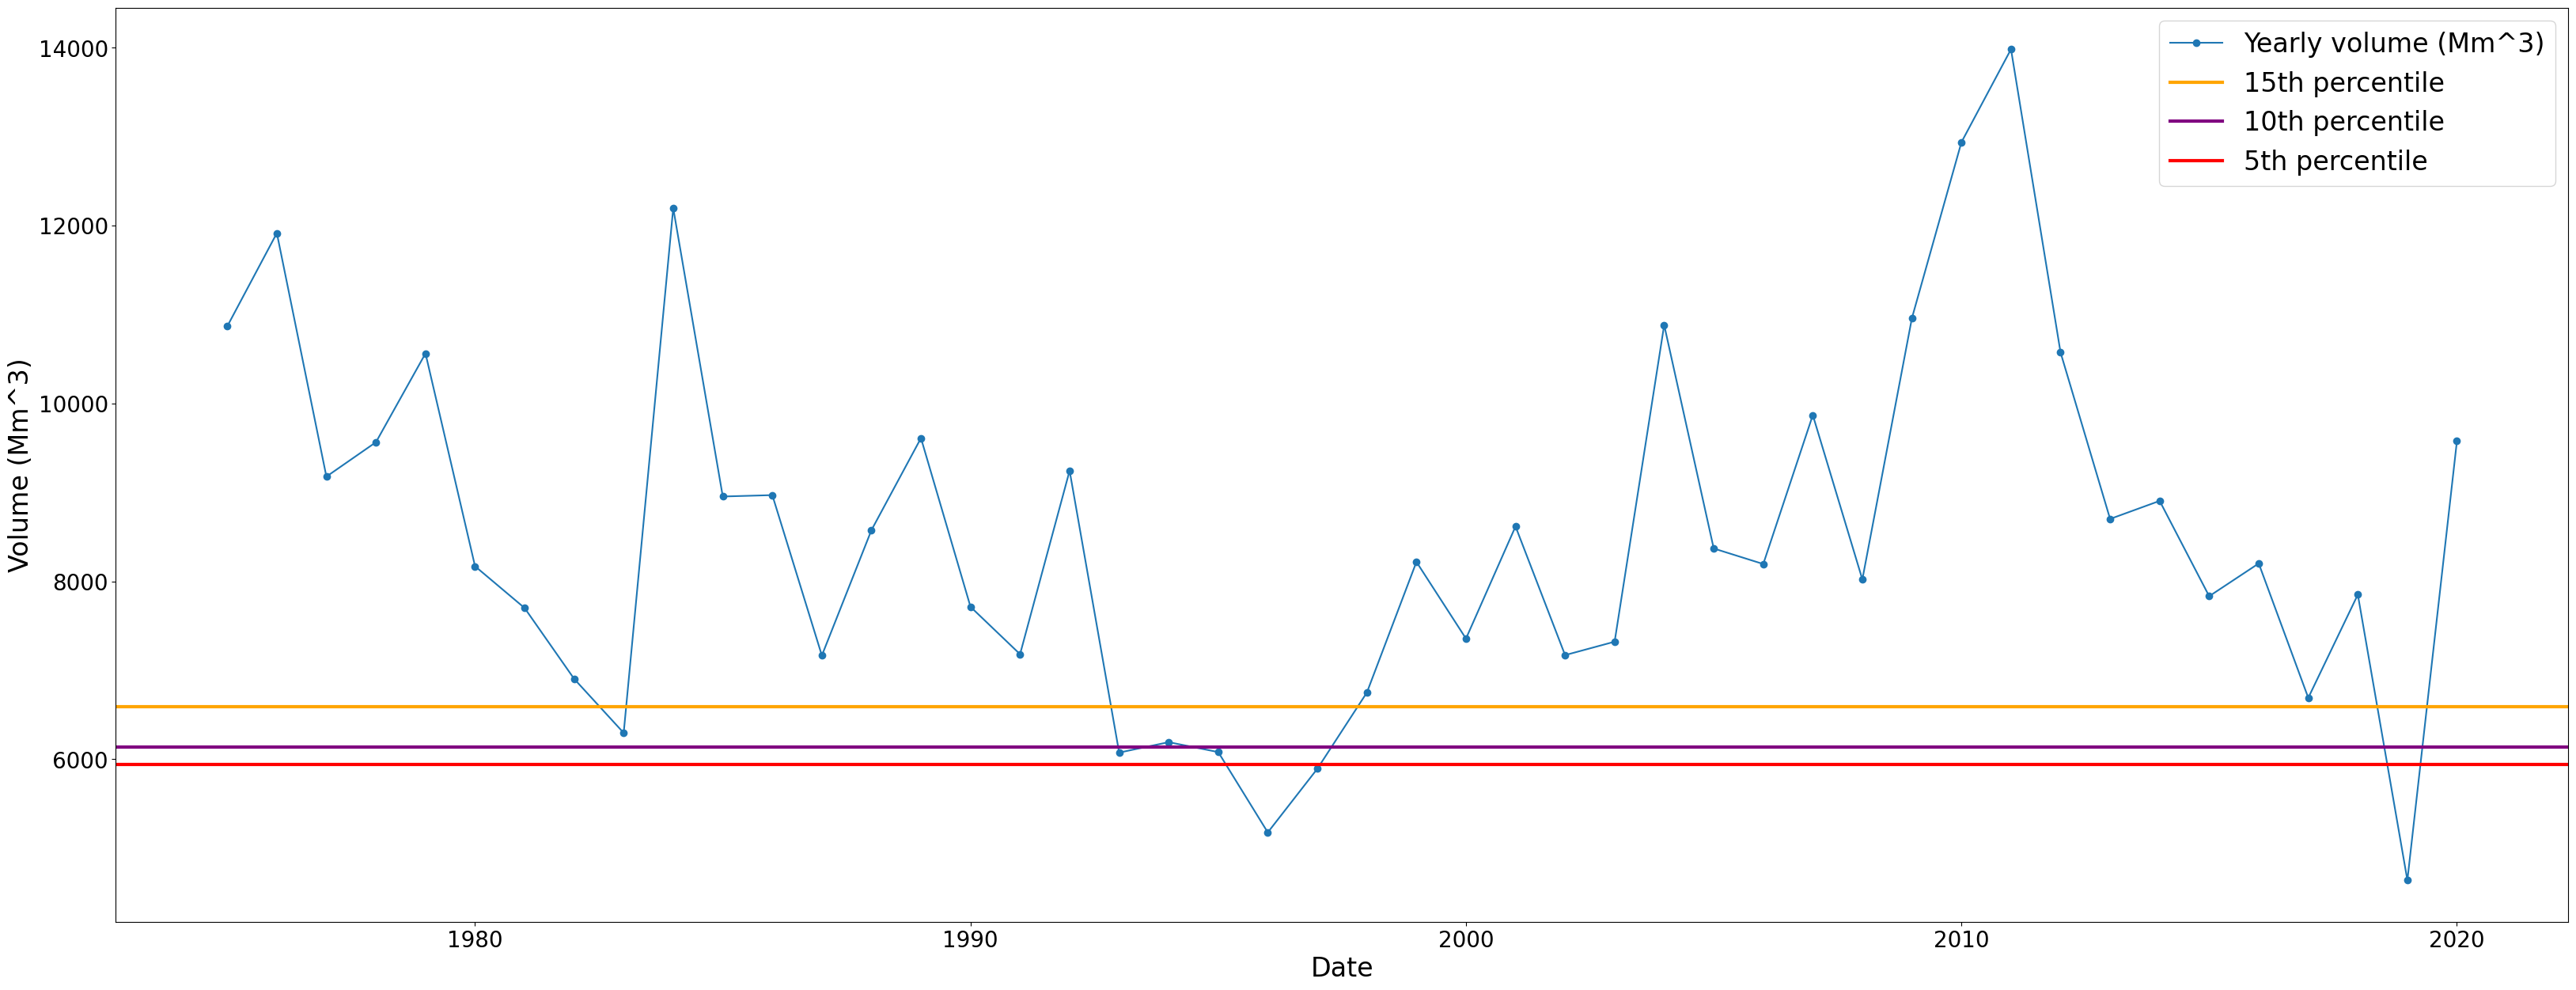

In [5]:
yearly_volume = (data_daily * 3600 * 24).resample('YE').sum() / 1e6
yearly_volume.index = yearly_volume.index.year
yearly_volume.columns = ['Yearly volume (Mm^3)']
Q_data = yearly_volume['Yearly volume (Mm^3)']

fig, ax = plt.subplots(figsize=(40, 15))
yearly_volume.plot(ax=ax, marker='o')
plt.axhline(y=np.percentile(Q_data, 15), color='orange', linewidth=3, label='15th percentile')
plt.axhline(y=np.percentile(Q_data, 10), color='purple', linewidth=3, label='10th percentile')
plt.axhline(y=np.percentile(Q_data, 5), color='red', linewidth=3, label='5th percentile')
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.set_xlabel("Date", fontsize=24)
ax.set_ylabel("Volume (Mm^3)", fontsize=24)
plt.legend(fontsize=24);

Determine months that are important to flooding

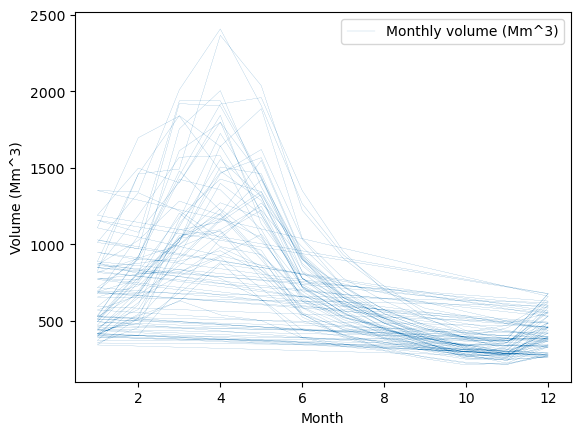

In [6]:
data_monthly = (data_daily * 3600 * 24).resample('ME').sum() / 1e6
data_monthly.index = data_monthly.index.month
data_monthly.columns = ['Monthly volume (Mm^3)']

fig, ax = plt.subplots()
data_monthly.plot(ax=ax, linewidth=0.1)
plt.xticks()
plt.yticks()
ax.set_xlabel("Month")
ax.set_ylabel("Volume (Mm^3)")
plt.legend();

Volume between months 2 and 7

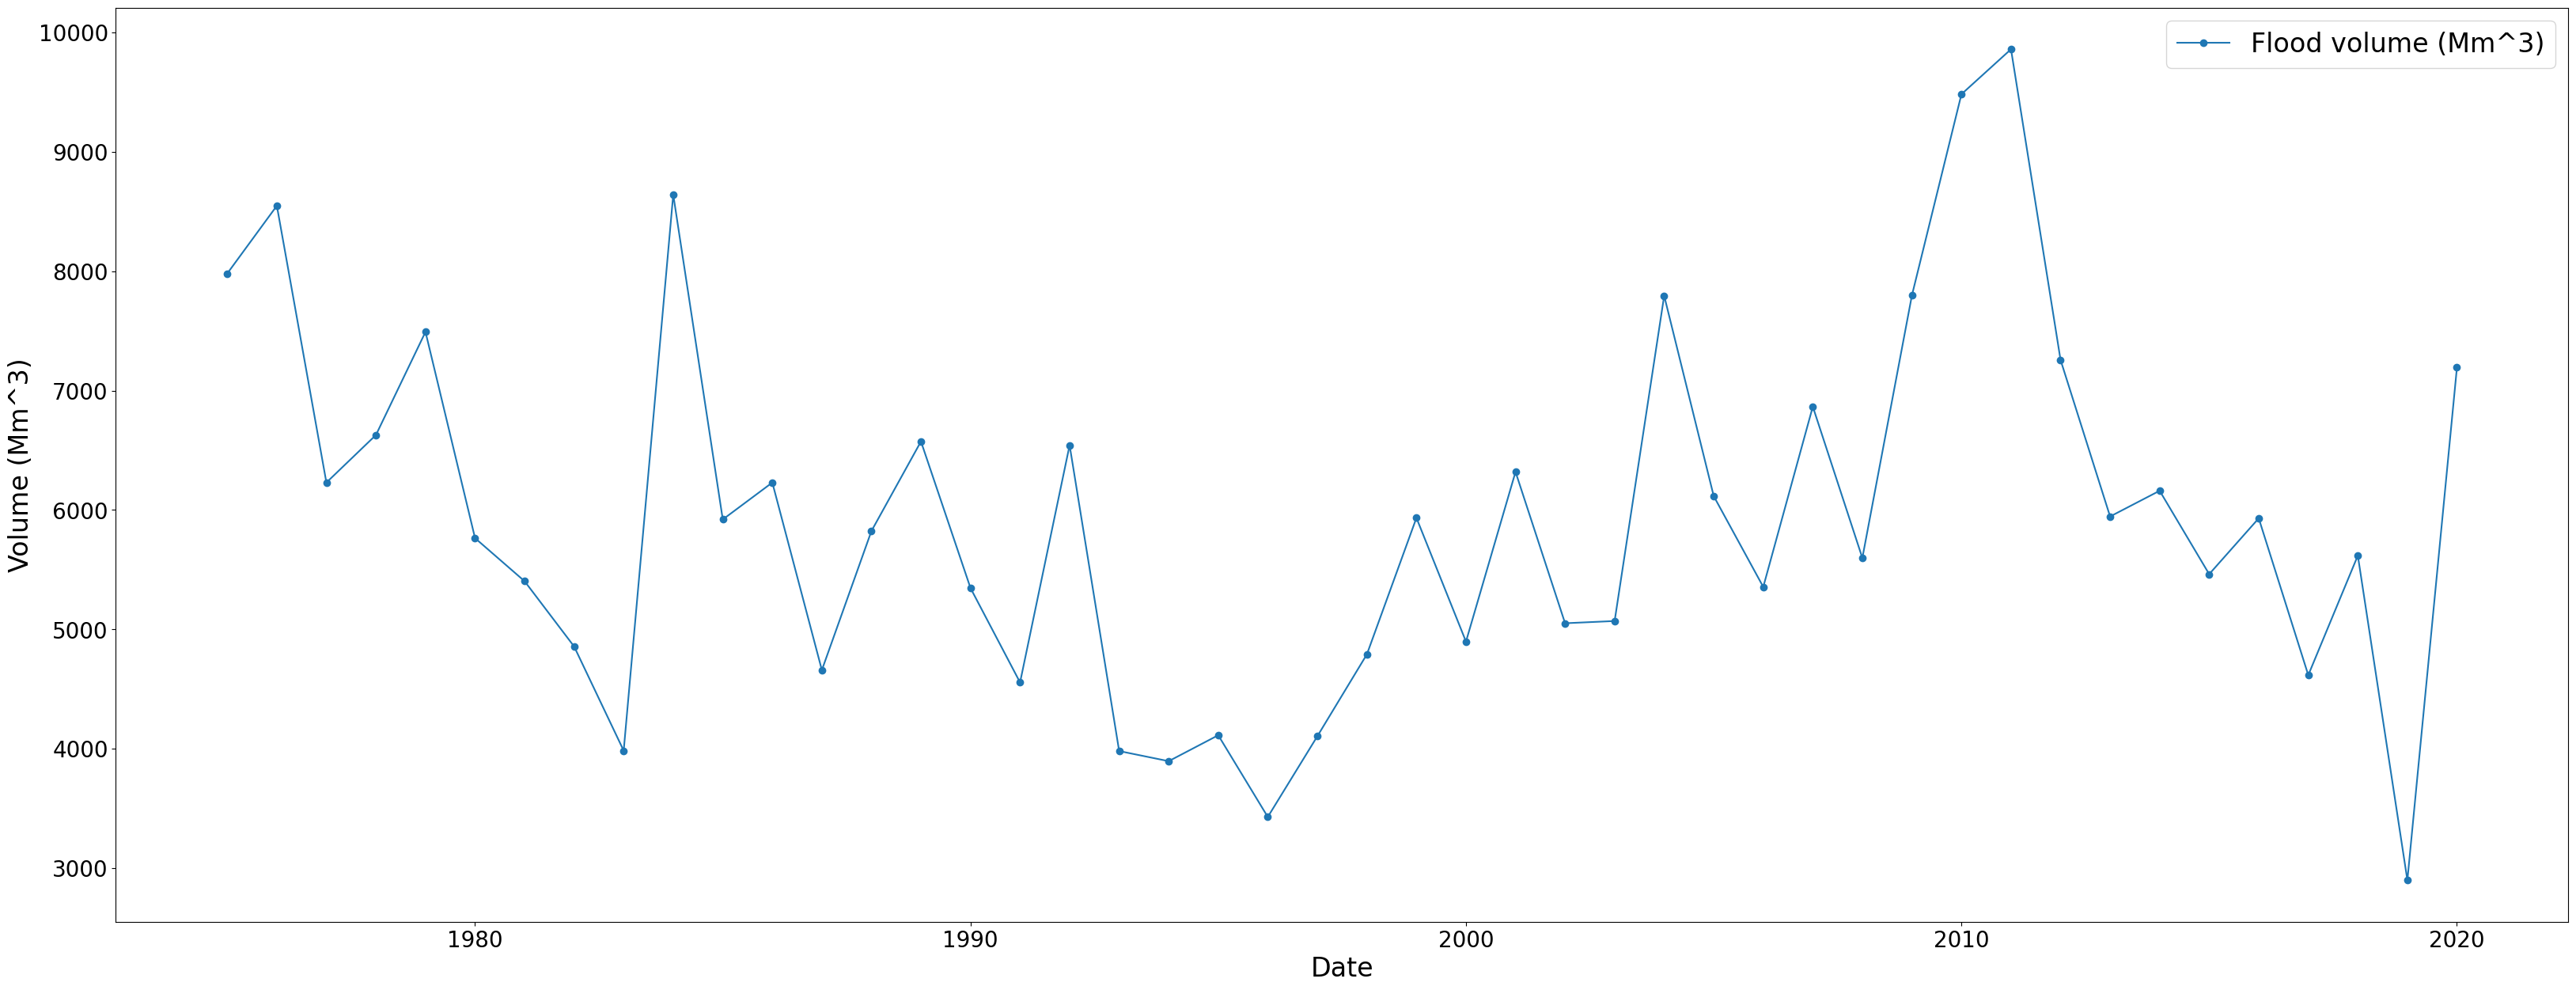

In [7]:
flood_volume = (data_daily * 3600 * 24)[data_daily.index.month.isin([2,3,4,5,6,7])].resample("YE").sum() / 1e6
flood_volume.index = flood_volume.index.year
flood_volume.columns = ['Flood volume (Mm^3)']

fig, ax = plt.subplots(figsize=(40, 15))
flood_volume.plot(ax=ax, marker='o')
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.set_xlabel("Date", fontsize=24)
ax.set_ylabel("Volume (Mm^3)", fontsize=24)
plt.legend(fontsize=24);

Plotting yearly volume and flood volume

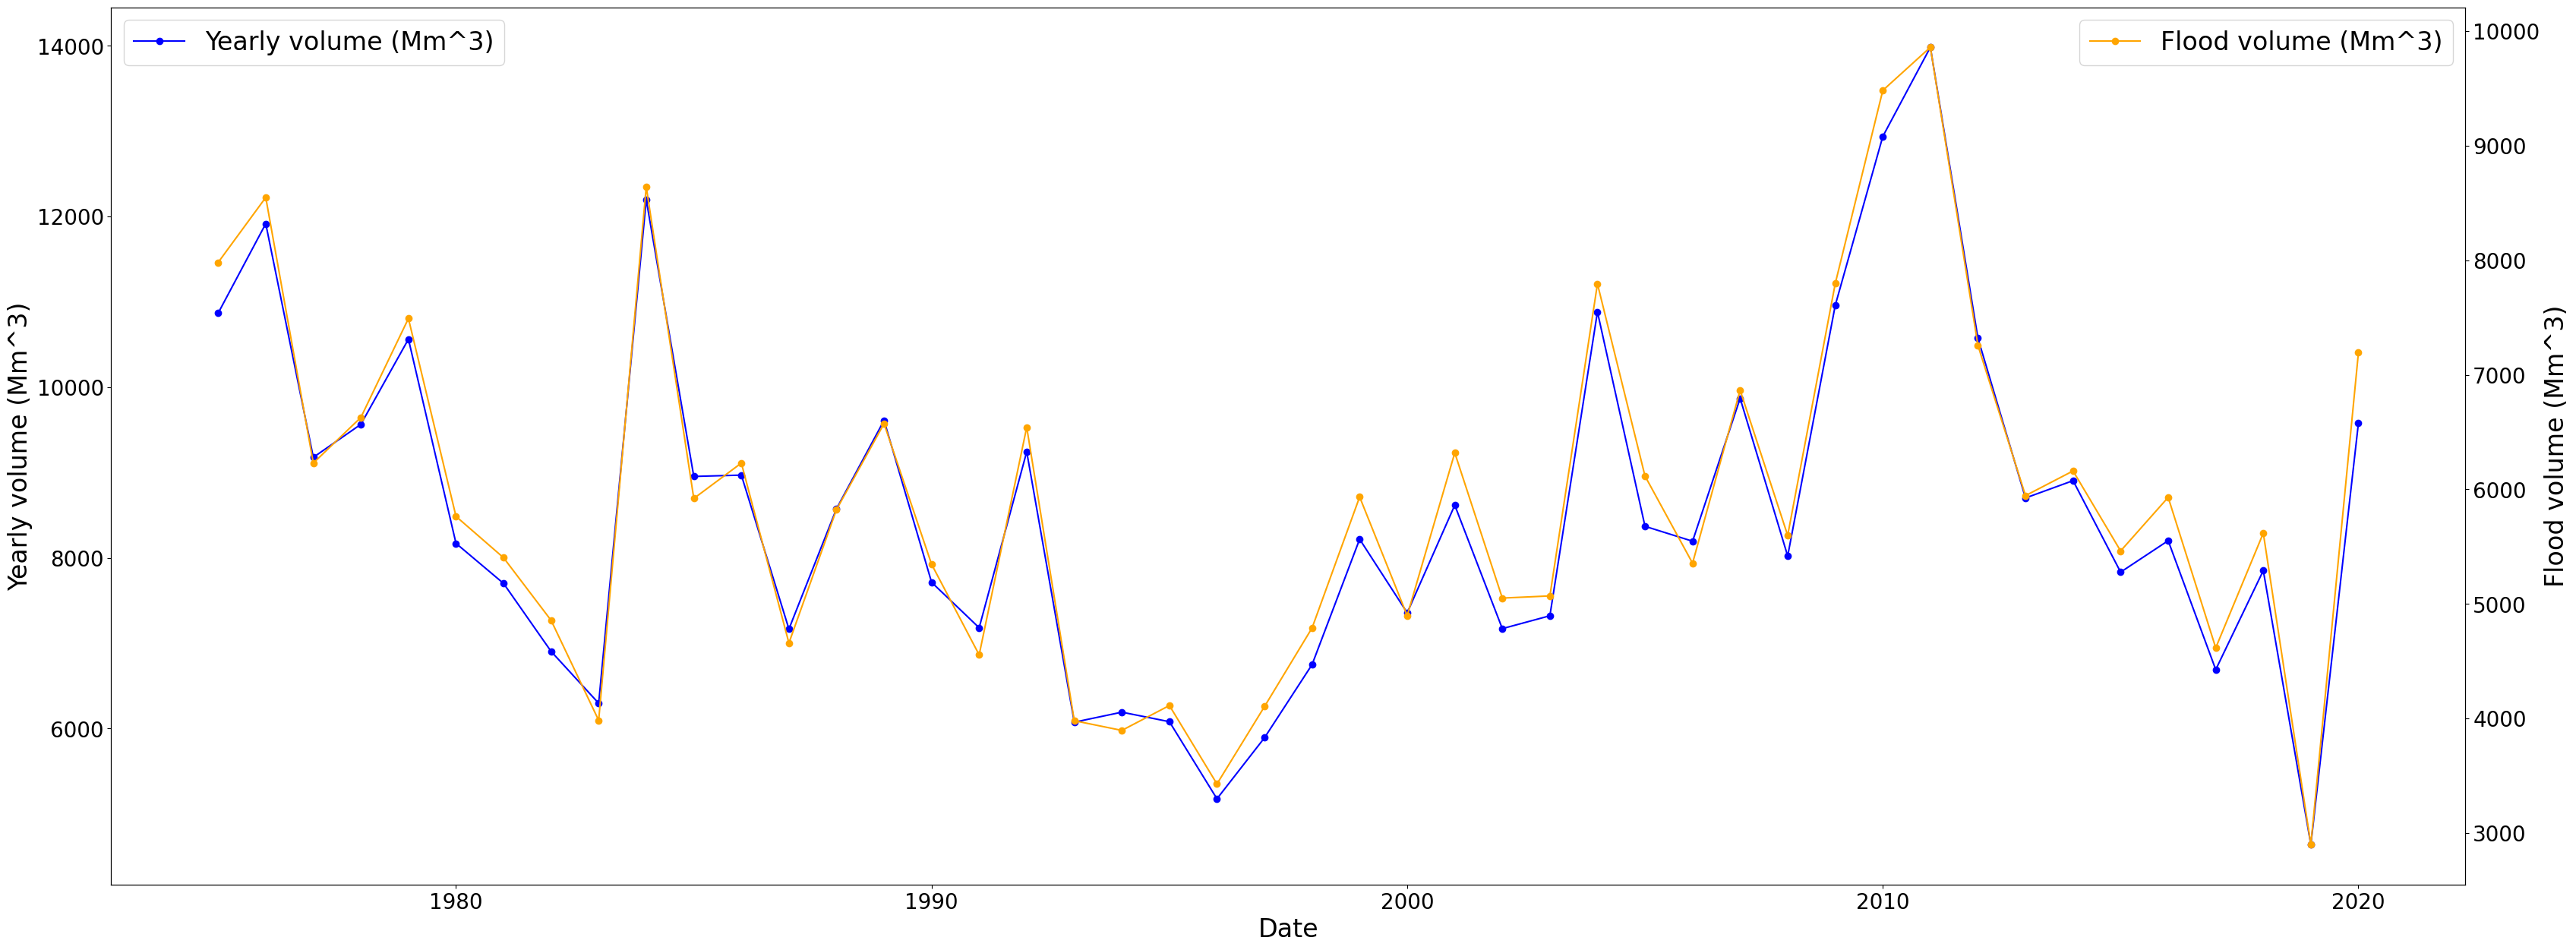

In [8]:
fig, ax = plt.subplots(figsize=(40, 15))
plt.xticks(fontsize=20)
yearly_volume.plot(ax=ax, marker='o', color='blue')
#plt.axhline(y=6300, color='purple', linewidth=3, label='Yearly volume threshold')
plt.yticks(fontsize=20)
ax.set_xlabel("Date", fontsize=24)
ax.set_ylabel("Volume (Mm^3)", fontsize=24)
plt.legend(fontsize=24, loc='upper left')

ax1 = ax.twinx()
flood_volume.plot(ax=ax1, marker='o', color='orange')
#plt.axhline(y=4150, color='red', linewidth=3, label='Flood volume threshold')
plt.yticks(fontsize=20)
plt.legend(fontsize=24, loc='upper right')

ax.set_xlabel("Date", fontsize=24)
ax.set_ylabel("Yearly volume (Mm^3)", fontsize=24)
ax1.set_ylabel("Flood volume (Mm^3)", fontsize=24);

Plotting yearly volume and yearly max discharge

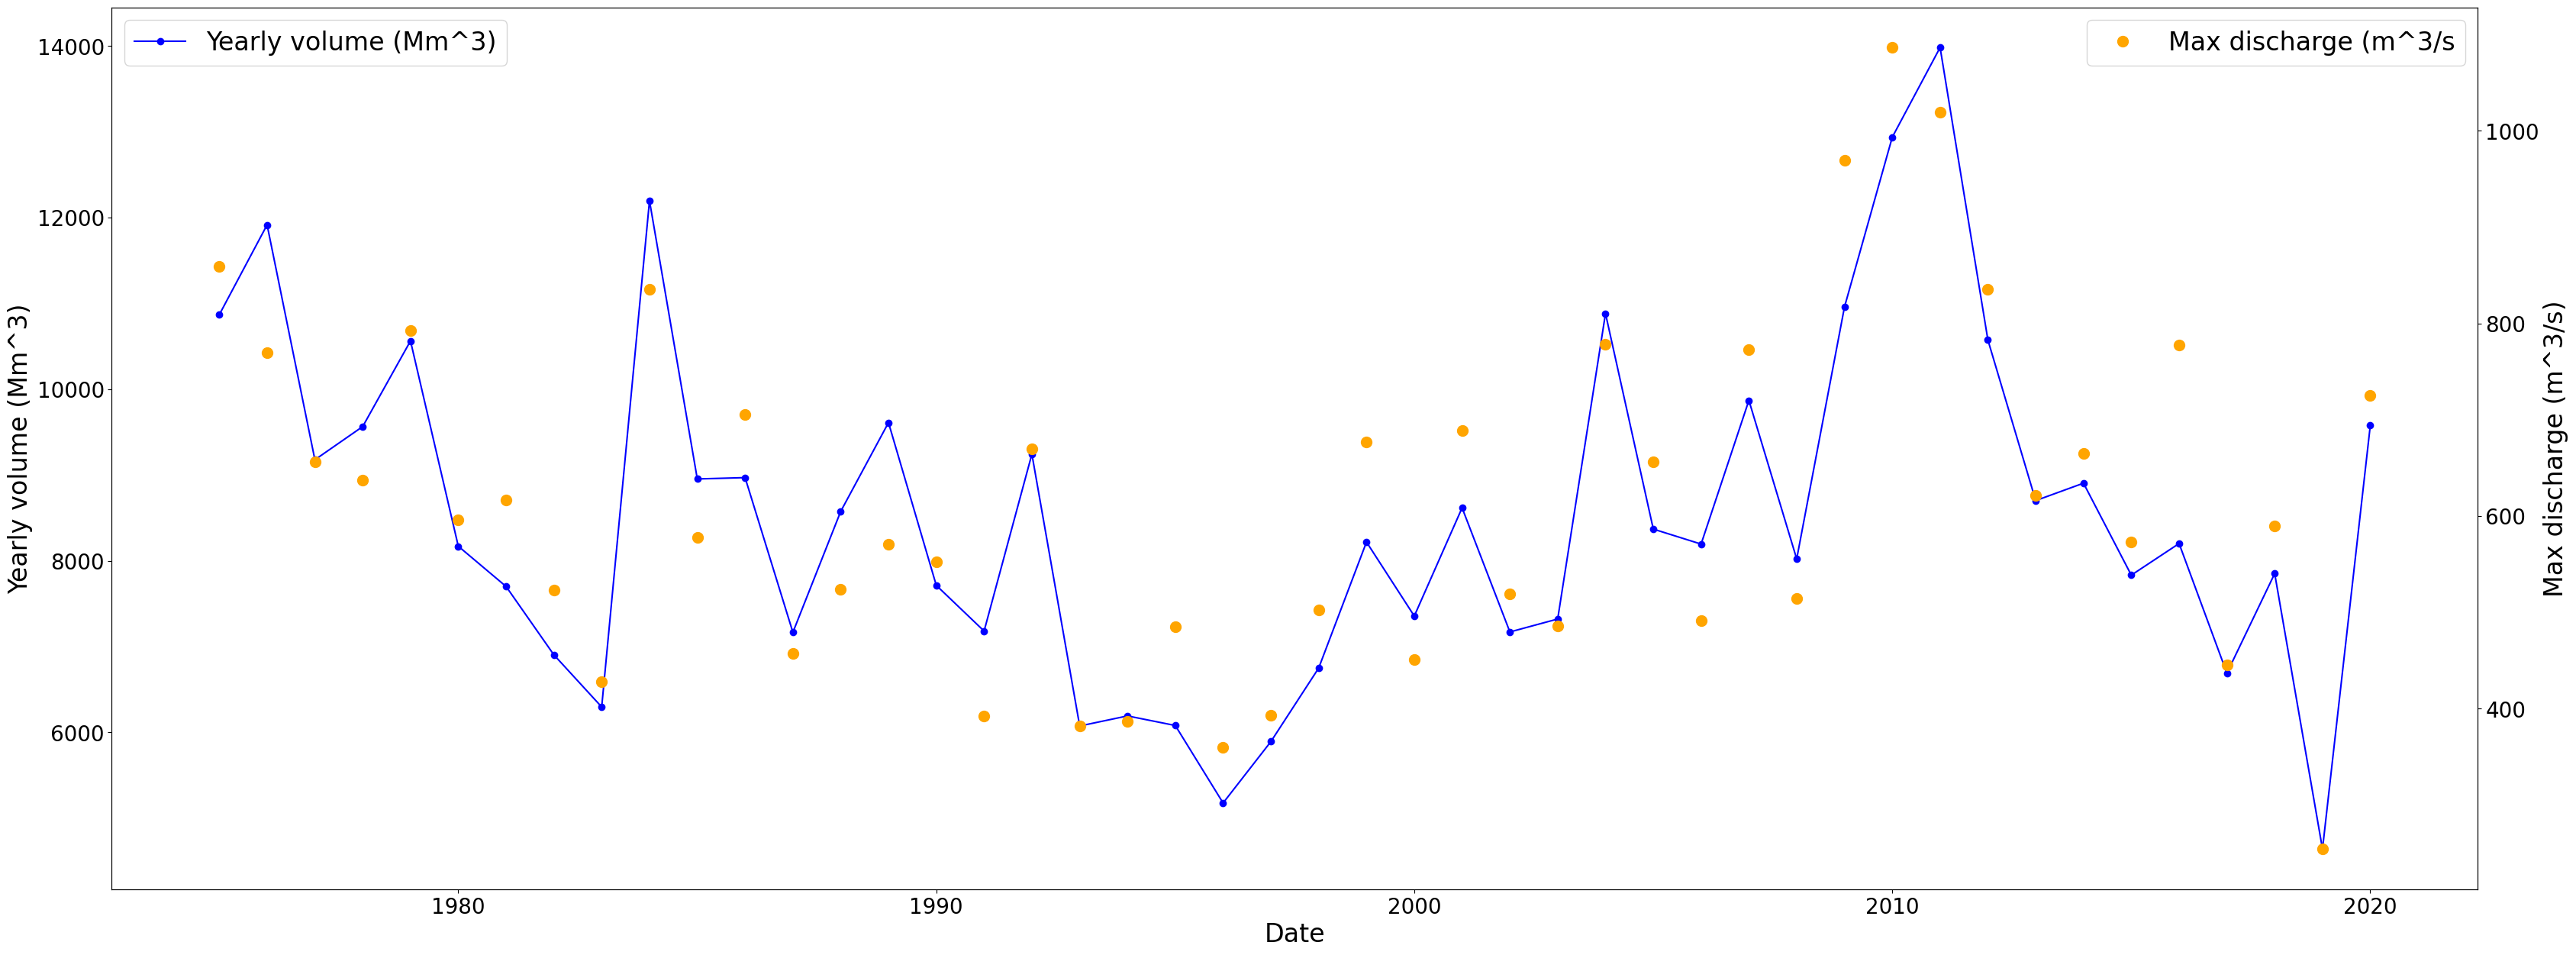

In [9]:
fig, ax = plt.subplots(figsize=(40, 15))
plt.xticks(fontsize=20)
yearly_volume.plot(ax=ax, marker='o', color='blue')
plt.yticks(fontsize=20)
ax.set_xlabel("Date", fontsize=24)
ax.set_ylabel("Volume (Mm^3)", fontsize=24)
plt.legend(fontsize=24, loc='upper left')

ax1 = ax.twinx()
yearly_max.plot(ax=ax1, marker='o', color='orange', linestyle='None', markersize=10)
plt.yticks(fontsize=20)
plt.legend(fontsize=24, loc='upper right')

ax.set_xlabel("Date", fontsize=24)
ax.set_ylabel("Yearly volume (Mm^3)", fontsize=24)
ax1.set_ylabel("Max discharge (m^3/s)", fontsize=24);

Plotting flood volume and yearly max

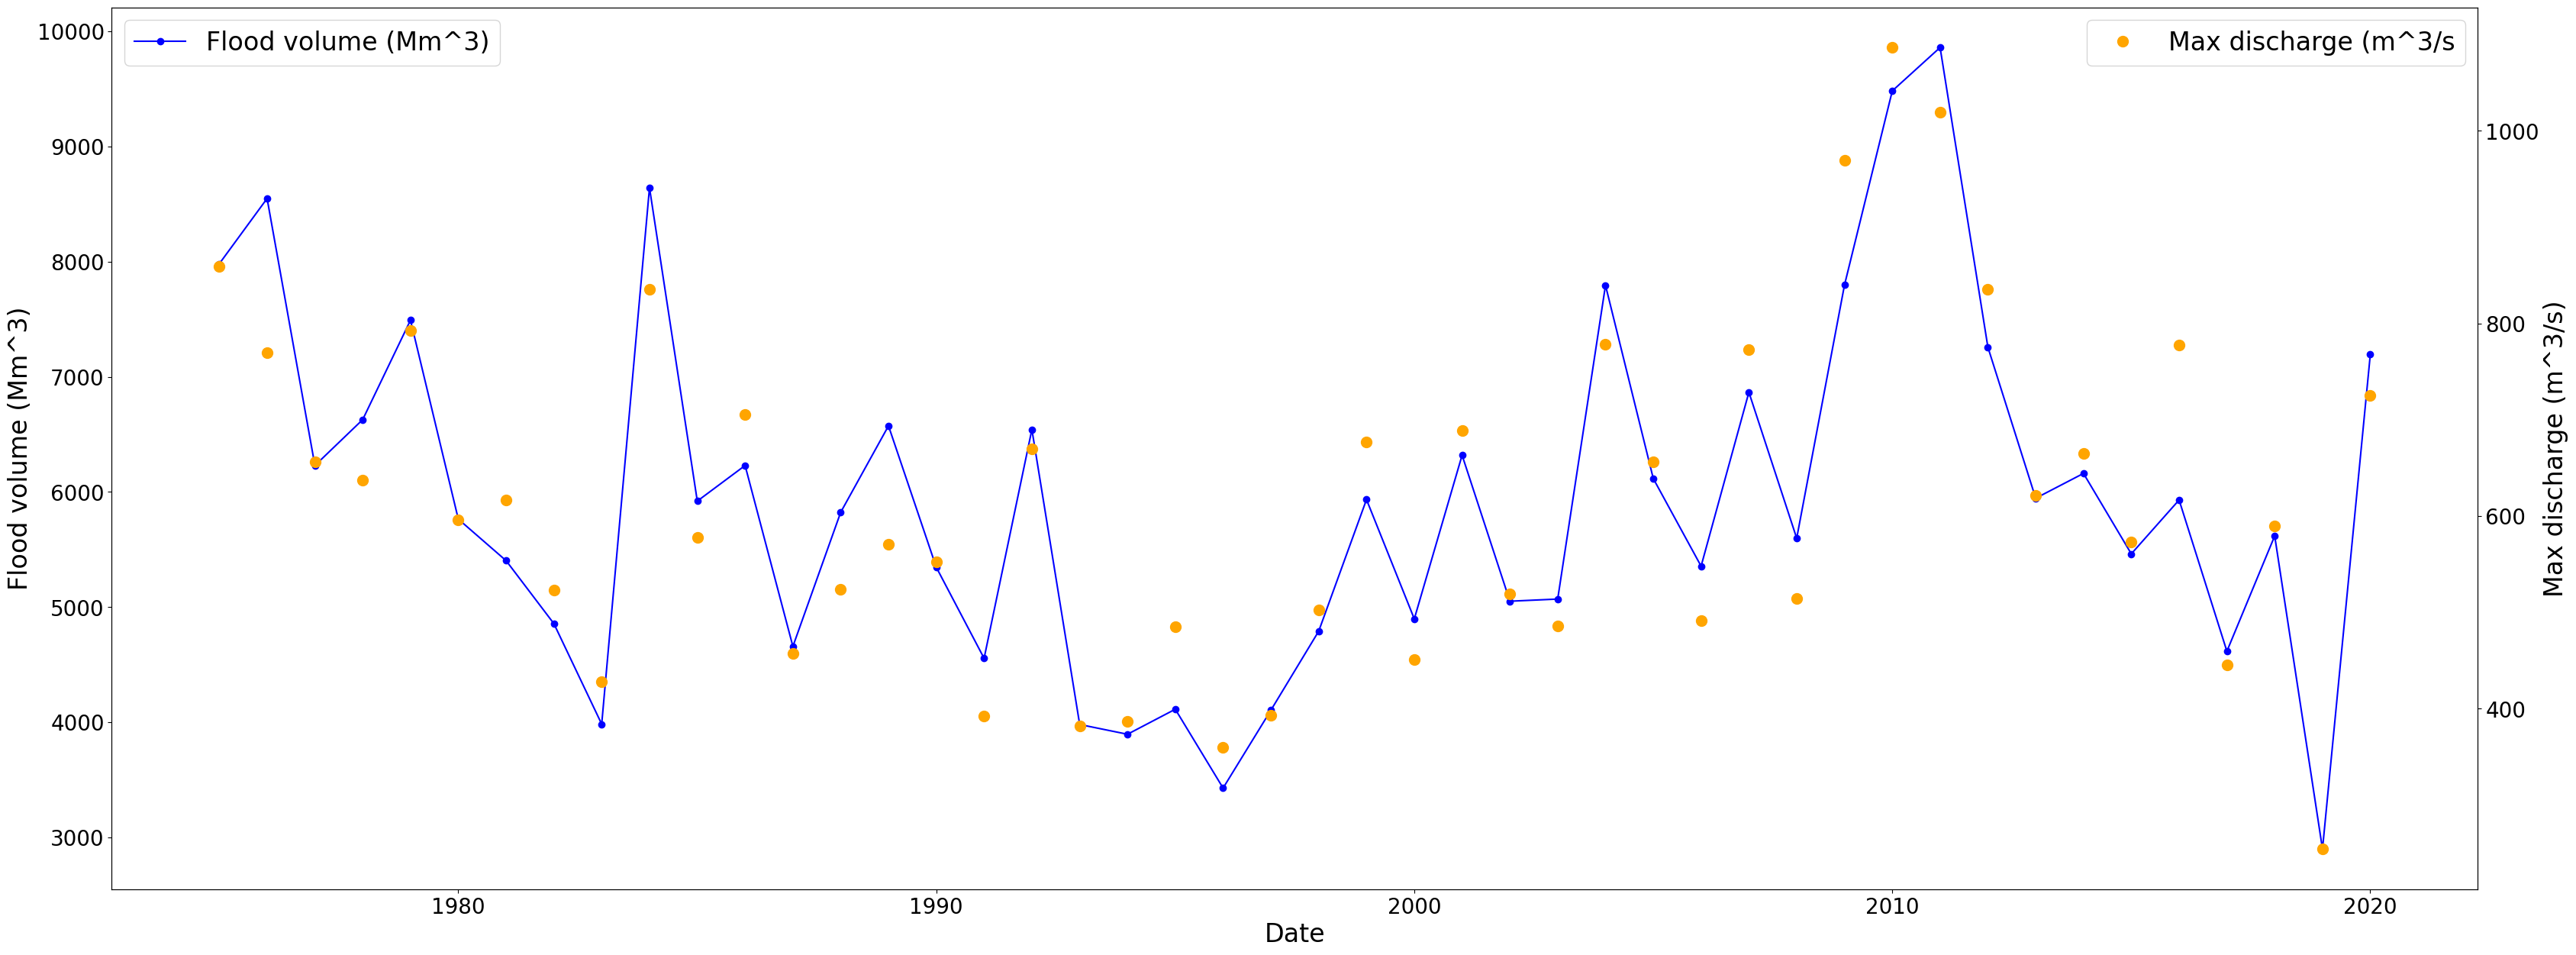

In [10]:
fig, ax = plt.subplots(figsize=(40, 15))
plt.xticks(fontsize=20)
flood_volume.plot(ax=ax, marker='o', color='blue')
plt.yticks(fontsize=20)
ax.set_xlabel("Date", fontsize=24)
ax.set_ylabel("Volume (Mm^3)", fontsize=24)
plt.legend(fontsize=24, loc='upper left')

ax1 = ax.twinx()
yearly_max.plot(ax=ax1, marker='o', color='orange', linestyle='None', markersize=10)
plt.yticks(fontsize=20)
plt.legend(fontsize=24, loc='upper right')

ax.set_xlabel("Date", fontsize=24)
ax.set_ylabel("Flood volume (Mm^3)", fontsize=24)
ax1.set_ylabel("Max discharge (m^3/s)", fontsize=24);

Detemining threshold values

In [11]:
a = yearly_max[(yearly_max < 0)]
a = a.dropna()

b = yearly_volume[(yearly_volume < 6590.85833332656)]
b = b.dropna()

c = flood_volume[(flood_volume < 4150)]
c = c.dropna()

abc = pd.concat([a, b, c], axis=1).sort_index()
abc

,Max discharge (m^3/s,Yearly volume (Mm^3),Flood volume (Mm^3)
date,,,
1983,NaN,6295.129812,3983.992678
1993,NaN,6073.525584,3980.780208
1994,NaN,6190.942493,3896.100000
1995,NaN,6079.328381,4113.261216
1996,NaN,5175.877018,3428.873856
1997,NaN,5891.672592,4104.730512
2019,NaN,4638.847870,2899.341276


Quantiles

In [12]:
yearly_volume_sorted = yearly_volume.sort_values(by='Yearly volume (Mm^3)')
print(yearly_volume_sorted.mean())
yearly_volume_sorted.head(8)

Yearly volume (Mm^3)    8516.9315
dtype: float64


,Yearly volume (Mm^3)
date,
2019,4638.847870
1996,5175.877018
1997,5891.672592
1993,6073.525584
1995,6079.328381
1994,6190.942493
1983,6295.129812
2017,6689.434507


In [13]:
Q_data = yearly_volume['Yearly volume (Mm^3)']
Q_yearly_volume = np.percentile(Q_data, 15)
print(Q_yearly_volume)

6590.85833332656


In [14]:
yearly_volume.mean()

Yearly volume (Mm^3)    8516.9315
dtype: float64

In [16]:
yearly_volume_sorted = np.sort(yearly_volume['Yearly volume (Mm^3)'])[::1]

def calculate_return_periods(sorted_model_data):
    n = len(sorted_model_data)
    rank = np.arange(1, n + 1)
    ReturnInterval = (n + 1) / rank
    ExceedenceProb = 1 / ReturnInterval * 100
    
    return ExceedenceProb, ReturnInterval

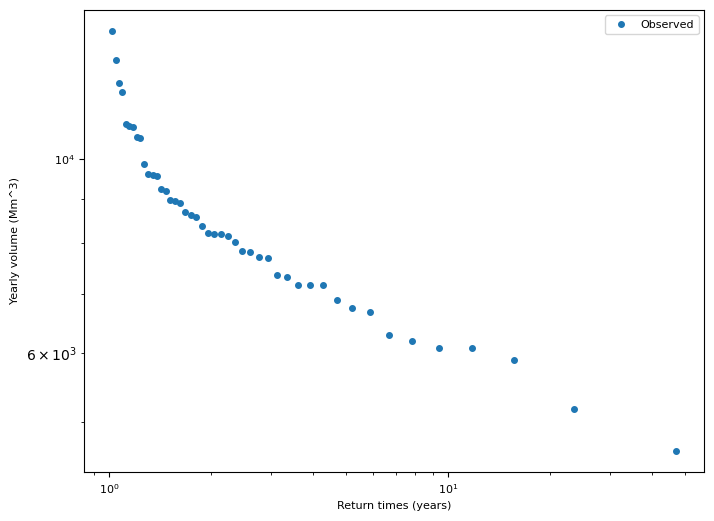

In [22]:
Observed_ExProb, Observed_return = calculate_return_periods(yearly_volume_sorted)

fig, ax = plt.subplots(figsize=(8, 6))
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
ax.set_xlabel("Return times (years)", fontsize=8)
ax.set_ylabel("Yearly volume (Mm^3)", fontsize=8)
plt.xscale('log')
plt.yscale('log')

plt.plot(Observed_return, yearly_volume_sorted, marker='o', linestyle='None', ms=4, label='Observed')
plt.legend(fontsize=8);